# Compare models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

import pickle
import sys
sys.path.append('../')
from pyEM.fitting import EMfit
from scipy.optimize import minimize
import likelihood_terms


In [ ]:
# Load 2 learning rate (no reward and reward)
with open('/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/BlancoPozo_optimal_fit_Nov2025/Fitting_code_hierarchical/model_comparison_jan2026/best_parameters_2LR_iter_byPart_optimized75_FEB3.pkl', 'rb')   as f:
    outputdict_all_2lr = pickle.load(f)

# Load 1 learning rate
with open(f'/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/BlancoPozo_optimal_fit_Nov2025/fitting_code_aws/hierarchical_fit_1lr_stay&forget_Feb2026/1lr_stay&forget_2025_parallel_hierNoSeed_fit_results_yfp_ALLSessions_1lr_crit01_Feb2026_30_01_2026_06_54_39.pkl', 'rb') as f:
    outputdict_all_1lr = pickle.load(f)

# assymetric forget to 0
with open(f'/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/BlancoPozo_optimal_fit_Nov2025/fitting_code_aws/hierarchical_fit_assymDecay0/asymModelBased_2025_parallel_hierNoSeed_fit_results_yfp_ALLSessions_1lr_crit01_Dec2025_18_12_2025_15_30_54.pkl', 'rb') as f:
    outputdict_all_asymDecay0 = pickle.load(f)

# model free
with open(f'/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/BlancoPozo_optimal_fit_Nov2025/fitting_code_aws/hierarchical_fit_modelFree/modelFree_parallel_hierNoSeed_fit_results_yfp_ALLSessions_1lr_crit01_18_12_2025_08_48_55.pkl', 'rb') as f:
    outputdict_all_modelFree = pickle.load(f)

# pure SR
with open(f'/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/BlancoPozo_optimal_fit_Nov2025/fitting_code_aws/hierarchical_fit_pureSR/pureSR_2025_parallel_hierNoSeed_fit_results_yfp_ALLSessions_1lr_crit01_Dec2025_18_12_2025_02_47_57.pkl', 'rb') as f:
    outputdict_all_pureSR = pickle.load(f)

# basic model based
with open(f'/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/BlancoPozo_optimal_fit_Nov2025/fitting_code_aws/hierarchical_fit_basicModelBased_Jan2026/BasicModelBased_2026_parallel_hierNoSeed_fit_results_yfp_ALLSessions_crit01_Dec2025_09_01_2026_12_43_19.pkl', 'rb') as f:
    outputdict_all_basicModelBased = pickle.load(f)

# transition learn model based
with open(f'/Users/pradyumnasepulveda/Library/CloudStorage/GoogleDrive-pradyumna.sepulvedadelgado@nyspi.columbia.edu/My Drive/Studies/Adithya_CausalLearning/BlancoPozo_optimal_fit_Nov2025/fitting_code_aws/hierarchical_fit_transLearnModelBased_Jan2026/TransitionLearnModelBased_2026_parallel_hierNoSeed_fit_results_yfp_ALLSessions_crit01_Dec2025_11_01_2026_23_50_41.pkl', 'rb') as f:
    outputdict_all_transLearnModelBased = pickle.load(f)


# Estimate hierarchical BIC

In [26]:


df_stim_opto = pd.read_pickle('../../../BlancoPozos_two-step_dopamine-main/Data/df_stim_opto.pkl')
df_YFP = df_stim_opto[df_stim_opto['virus'] == 'YFP']
df_YFP_outcome_cue = df_YFP
df_YFP_subjectwise = {subject: df for subject, df in df_YFP_outcome_cue.groupby('subject')}


all_subject_items = {}

for sid in df_YFP_subjectwise.keys():
    df_YFP_sessionLv = df_YFP_subjectwise[sid]
    subject_items = []

    for j in range(len(df_YFP_sessionLv)):
        sess_num = pd.DataFrame.from_dict(
            df_YFP_sessionLv.iloc[j].sessions.trial_data
        ).apply(pd.to_numeric, errors='coerce').fillna(0)

        transition_type_foo = df_YFP_sessionLv.iloc[j].sessions.blocks['trial_trans_state']
        sess_num['transition_type'] = transition_type_foo



        if len(sess_num) > 200:
            print(f'Subject {sid}, Session {j}, Number of trials: {len(sess_num)}')

            subject_items.append(sess_num)

    all_subject_items[sid] = subject_items




Subject 63, Session 1, Number of trials: 256
Subject 63, Session 2, Number of trials: 286
Subject 63, Session 3, Number of trials: 303
Subject 63, Session 4, Number of trials: 271
Subject 63, Session 5, Number of trials: 300
Subject 63, Session 6, Number of trials: 240
Subject 63, Session 9, Number of trials: 380
Subject 63, Session 10, Number of trials: 367
Subject 63, Session 11, Number of trials: 337
Subject 63, Session 12, Number of trials: 359
Subject 63, Session 13, Number of trials: 340
Subject 63, Session 14, Number of trials: 329
Subject 63, Session 15, Number of trials: 289
Subject 63, Session 16, Number of trials: 395
Subject 63, Session 17, Number of trials: 437
Subject 63, Session 18, Number of trials: 409
Subject 63, Session 19, Number of trials: 348
Subject 63, Session 20, Number of trials: 419
Subject 63, Session 21, Number of trials: 395
Subject 63, Session 22, Number of trials: 360
Subject 63, Session 23, Number of trials: 372
Subject 63, Session 24, Number of trials:

In [27]:
import SRCG_utils as model_utils
import likelihood_terms_2026 as lt


In [28]:
from scipy.special import logsumexp

# Storage for all model comparisons
all_bic_results = {}
all_bic_overall = {}

lls_sessions_rep = {}


In [29]:

for model_name_in in ['base_2lr', 'base_1lr', 'asymDecay0', 'mf', 'pureSR','mb','mb_transition']:
# for model_name_in in ['mb_transition']:

    # Define likelihood function mapping
    likelihood_functions = {
        'base_2lr': lt.likelihood_term_free_free_noStim_2lr_stay_forget,
        'base_1lr': lt.likelihood_term_free_free_noStim_1lr_stay_forget,
        # 'base_2lr': lt.likelihood_term_base_2lr,
        # 'base_4lr': lt.likelihood_term_base_4lr,
        'pureSR': lt.likelihood_term_nostim_pureSR,
        'mf': lt.likelihood_term_mf,
        'asymDecay0': lt.likelihood_term_asymmetric_model_based,
        'mb': lt.likelihood_term_basic_model_based,
        'mb_transition': lt.likelihood_term_transition_model_based
    }

    # Define the model parameters to be used


    if model_name_in == 'base_2lr':
        outputdict_all_test = outputdict_all_2lr.copy()
    elif model_name_in == 'base_1lr':
        outputdict_all_test = outputdict_all_1lr.copy()
    elif model_name_in == 'asymDecay0':
        outputdict_all_test = outputdict_all_asymDecay0.copy()
    elif model_name_in == 'mf':
        outputdict_all_test = outputdict_all_modelFree.copy()
    elif model_name_in == 'pureSR':
        outputdict_all_test = outputdict_all_pureSR.copy()
    elif model_name_in == 'mb':
        outputdict_all_test = outputdict_all_basicModelBased.copy()
    elif model_name_in == 'mb_transition':
        outputdict_all_test = outputdict_all_transLearnModelBased.copy()


    # ============ CHOOSE MODEL HERE ============
    model_name = model_name_in  # Change this to: 'base_2lr', 'mf', 'pureSR', etc.
    likelihood_func = likelihood_functions[model_name]
    # ===========================================

    samplesize = 8000 # Number of samples to draw from posterior

    # Storage - rename 'bics' to 'log_likelihoods' for clarity
    log_likelihoods = {}
    l_session = {}
    choice_NLL_session = {}

    # Loop over subjects
    for sub_i in outputdict_all_test.keys():
        outputdict_part = outputdict_all_test[sub_i].copy()
        n_parameters = len(outputdict_part['posterior']['mu']) * 2
        

        # if model_name == 'base_2lr':
        #     theta_mean = outputdict_part['posterior_mean_traj'][item_min[sub_i]]
        #     theta_sigma0 = outputdict_part['posterior_sigma_traj'][item_min[sub_i]]
        # elif model_name == 'base_1lr':
        #     theta_mean = outputdict_part['posterior_mean_traj'][item_min2[sub_i]]
        #     theta_sigma0 = outputdict_part['posterior_sigma_traj'][item_min2[sub_i]]
        # else:
        theta_mean = outputdict_part['posterior']['mu']
        theta_sigma0 = outputdict_part['posterior']['sigma']
        theta_sigma = np.diag(theta_sigma0)  # Convert to covariance matrix
        
        np.random.seed(10)
        hs = np.random.multivariate_normal(mean=theta_mean, cov=theta_sigma, size=samplesize)
        
        subj_sessions_list = all_subject_items[sub_i].copy()
        
        log_likelihoods[sub_i] = []
        l_session[sub_i] = []
        choice_NLL_session[sub_i] = []
        
        # Loop over sessions
        for fi in range(len(subj_sessions_list)):
            # Unpack data
            free_choice, transitions, choices, outcomes, second_steps, stims, n_episodes, transition_type = \
                model_utils.import_data_withTransType(subj_sessions_list[fi])
            
            free_choice = free_choice.to_numpy()
            transitions = transitions.to_numpy()
            choices = choices.to_numpy()
            outcomes = outcomes.to_numpy()
            second_steps = second_steps.to_numpy()
            stims = stims.to_numpy()
            transition_type = transition_type.astype(bool)
            
            # Parallel computation of NLL for each sample
            from joblib import Parallel, delayed
            
            def compute_single_nll(x_sample, model_type):
                """Compute NLL for a single parameter sample"""
                if model_type == 'asymDecay0' or model_type == 'mb' or model_type == 'mb_transition':
                    return likelihood_func(x_sample, free_choice, transitions, 
                                         choices, outcomes, second_steps, 
                                         stims, n_episodes, transition_type)
                else:
                    return likelihood_func(x_sample, free_choice, transitions, 
                                         choices, outcomes, second_steps, 
                                         stims, n_episodes)
            
            # Run in parallel with -1 jobs (all available cores)
            CHOICE_NLL = np.array(Parallel(n_jobs=-1)(
                delayed(compute_single_nll)(hs[i], model_name) 
                for i in range(samplesize)
            ))
            
            # Log-sum-exp trick for log(mean(exp(-NLL)))
            log_marginal_lik = logsumexp(-CHOICE_NLL) - np.log(samplesize)
            
            log_likelihoods[sub_i].append(log_marginal_lik)
            l_session[sub_i].append(len(choices))
            choice_NLL_session[sub_i].append(CHOICE_NLL)



    # Compute BIC scores
    bic_score_ind = {}
    for sub_i in outputdict_all_test.keys():
        if model_name == 'base_2lr':
            n_params_subj = (len(outputdict_all_test[sub_i]['posterior']['mu']) * 2) 
        else:
            n_params_subj = len(outputdict_all_test[sub_i]['posterior']['mu']) * 2
        bic_score_ind[sub_i] = (-2 * np.sum(log_likelihoods[sub_i]) + 
                                n_params_subj * np.log(np.sum(l_session[sub_i])))

    # Overall BIC
    # n_subjects = len(outputdict_all_test.keys())
    # total_params = sum([(len(outputdict_all_test[s]['posterior']['mu']) * 2) - 1 if model_name == 'base_2lr' else (len(outputdict_all_test[s]['posterior']['mu']) * 2)
    #                     for s in outputdict_all_test.keys()])
    
    # print(f"Total parameters across subjects: {total_params}")
    # n_total_trials = sum([np.sum(l_session[s]) for s in outputdict_all_test.keys()])

    # bic_score_all = (-2 * sum([np.sum(log_likelihoods[s]) for s in log_likelihoods.keys()]) + 
    #                 n_subjects * total_params * np.log(n_total_trials))

    # Overall BIC, add up individual BICs


    bic_score_all = np.sum(list(bic_score_ind.values()))

    # Store results for later comparison
    all_bic_results[model_name] = bic_score_ind.copy()
    all_bic_overall[model_name] = bic_score_all
    lls_sessions_rep[model_name] = choice_NLL_session.copy() 



    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"Overall BIC: {bic_score_all:.2f}")
    print(f"{'='*50}\n")
    print(f"Individual BICs:")
    for subj, bic in bic_score_ind.items():
        print(f"  Subject {subj}: {bic:.2f}")


Model: base_2lr
Overall BIC: 38536.94

Individual BICs:
  Subject 63: 5515.00
  Subject 75: 7518.10
  Subject 66: 7400.99
  Subject 69: 8715.18
  Subject 71: 9387.68

Model: base_1lr
Overall BIC: 39056.61

Individual BICs:
  Subject 66: 7769.29
  Subject 75: 7552.36
  Subject 63: 5543.22
  Subject 69: 8723.85
  Subject 71: 9467.90

Model: asymDecay0
Overall BIC: 55991.02

Individual BICs:
  Subject 69: 12394.01
  Subject 75: 10585.38
  Subject 71: 13116.18
  Subject 63: 9200.85
  Subject 66: 10694.61

Model: mf
Overall BIC: 78303.37

Individual BICs:
  Subject 71: 18002.49
  Subject 69: 17767.26
  Subject 66: 14565.83
  Subject 63: 13648.19
  Subject 75: 14319.59

Model: pureSR
Overall BIC: 60895.96

Individual BICs:
  Subject 71: 14606.41
  Subject 75: 11614.88
  Subject 66: 11461.85
  Subject 69: 13967.96
  Subject 63: 9244.86

Model: mb
Overall BIC: 64489.18

Individual BICs:
  Subject 69: 14121.83
  Subject 63: 11459.34
  Subject 66: 12089.35
  Subject 75: 12159.32
  Subject 71: 1

In [45]:
# # save pickle
with open('negative_lls_for_model_comparison_stay&forget_optimzed75_4Feb2026_extras.pkl', 'wb') as f:
    pickle.dump(lls_sessions_rep, f)


In [31]:

# open pickle
# with open('negative_lls_for_model_comparison_Jan2026.pkl', 'rb') as f:
#     lls_sessions_rep = pickle.load(f)


In [64]:
# Pick random log-likelihood for each session and compute BIC (repeated sampling)
# lls_sessions_rep contains simulated log-likelihoods for each model/subject/session/sample

n_repetitions = 4000  # Number of random samples to draw

print("\n" + "="*70)
print(f"Computing BIC distribution by randomly sampling {n_repetitions} times")
print("(each time: randomly select one log-likelihood per session)")
print("="*70)

bic_random_samples_dist = {}  # Store distribution of BICs for each model

for model_name in lls_sessions_rep.keys():
# for model_name in ['base_2lr','base_1lr','pureSR']:


    if model_name == 'base_2lr':
        outputdict_all_test = outputdict_all_2lr.copy()
    elif model_name == 'base_1lr':
        outputdict_all_test = outputdict_all_1lr.copy()
    elif model_name == 'asymDecay0':
        outputdict_all_test = outputdict_all_asymDecay0.copy()
    elif model_name == 'mf':
        outputdict_all_test = outputdict_all_modelFree.copy()
    elif model_name == 'pureSR':
        outputdict_all_test = outputdict_all_pureSR.copy()
    elif model_name == 'mb':
        outputdict_all_test = outputdict_all_basicModelBased.copy()
    elif model_name == 'mb_transition':
        outputdict_all_test = outputdict_all_transLearnModelBased.copy()




        
    print(f"\nProcessing {model_name}...")
    
    overall_bic_list = []  # Store overall BIC for each repetition
    
    # Repeat random sampling
    for rep in range(n_repetitions):
        bic_by_subject = {}
        
        # Loop through subjects
        for sub_i in lls_sessions_rep[model_name].keys():
            sessions_data = lls_sessions_rep[model_name][sub_i]  # dict of sessions
            
            # Get number of parameters for this model/subject
            if model_name == 'base_2lr':
                n_params = (len(outputdict_all_test[sub_i]['posterior']['mu']) * 2) 
            else:
                n_params = len(outputdict_all_test[sub_i]['posterior']['mu']) * 2
            
            # Randomly pick one log-likelihood per session and sum them
            total_ll = 0
            total_trials = 0
            
            for sessidx in range(len(sessions_data)):
                session_lls = sessions_data[sessidx]
                # session_lls is array of log-likelihoods, one for each parameter sample
                # Randomly pick one
                # random_idx = np.random.randint(0, len(session_lls))
                samplesizelocal = 2000


                isNa = True
                while isNa:
                    random_idx = np.random.randint(0, len(session_lls), size = samplesizelocal)

                    # random_ll = -np.mean(session_lls[random_idx])
                    random_nll= logsumexp(-session_lls[random_idx]) - np.log(samplesizelocal)
                    if ~np.isnan(random_nll):
                        break
                
                # Convert neg log-likelihood to LL
                ll_session = random_nll
                total_ll += ll_session
                
                # Get number of trials in this session
                n_trials_session = len(all_subject_items[sub_i][sessidx])
                total_trials += n_trials_session
            
            # Compute BIC for this subject: BIC = -2*LL + k*ln(N)
            bic = -2 * total_ll + n_params * np.log(total_trials)
            bic_by_subject[sub_i] = bic
        
        # Compute overall BIC for this repetition
        overall_bic = np.sum(list(bic_by_subject.values()))
        overall_bic_list.append(overall_bic)
        
        # Print progress
        if (rep + 1) % 1000 == 0:
            print(f"  Completed {rep + 1}/{n_repetitions} repetitions")
    
    # Store distribution
    bic_random_samples_dist[model_name] = overall_bic_list

# Print statistics
print(f"\n{'='*70}")
print("BIC Distribution Statistics")
print(f"{'='*70}")
print(f"{'Model':<15} | {'Mean BIC':<12} | {'Std Dev':<12} | {'95% CI Lower':<12} | {'95% CI Upper':<12}")
print(f"{'-'*70}")

for model_name in bic_random_samples_dist.keys():
    bics = np.array(bic_random_samples_dist[model_name])
    mean_bic = np.mean(bics)
    std_bic = np.std(bics)
    ci_lower = np.percentile(bics, 2.5)
    ci_upper = np.percentile(bics, 97.5)
    
    print(f"{model_name:<15} | {mean_bic:>12.2f} | {std_bic:>12.2f} | {ci_lower:>12.2f} | {ci_upper:>12.2f}")

print(f"{'='*70}\n")

# include significant differences between the models



Computing BIC distribution by randomly sampling 4000 times
(each time: randomly select one log-likelihood per session)

Processing base_2lr...
  Completed 1000/4000 repetitions
  Completed 2000/4000 repetitions
  Completed 3000/4000 repetitions
  Completed 4000/4000 repetitions

Processing base_1lr...
  Completed 1000/4000 repetitions
  Completed 2000/4000 repetitions
  Completed 3000/4000 repetitions
  Completed 4000/4000 repetitions

Processing asymDecay0...
  Completed 1000/4000 repetitions
  Completed 2000/4000 repetitions
  Completed 3000/4000 repetitions
  Completed 4000/4000 repetitions

Processing mf...
  Completed 1000/4000 repetitions
  Completed 2000/4000 repetitions
  Completed 3000/4000 repetitions
  Completed 4000/4000 repetitions

Processing pureSR...
  Completed 1000/4000 repetitions
  Completed 2000/4000 repetitions
  Completed 3000/4000 repetitions
  Completed 4000/4000 repetitions

Processing mb...
  Completed 1000/4000 repetitions
  Completed 2000/4000 repetitions


In [65]:
from scipy import stats
import pandas as pd
import itertools

# Prepare data for pairwise t-tests
model_names = list(bic_random_samples_dist.keys())
model_bics = {model: np.array(bic_random_samples_dist[model]) for model in model_names}

print("=" * 80)
print("PAIRWISE T-TESTS: Model BIC Comparisons")
print("=" * 80)
print("\nNull Hypothesis: Two models have equal mean BIC")
print("Alternative: Models have significantly different BIC (two-tailed)")
print("\nNote: Lower BIC = better model. If p < 0.05, models differ significantly.\n")

# Create results table
results_data = []

# Perform all pairwise comparisons
for model1, model2 in itertools.combinations(model_names, 2):
    bic1 = model_bics[model1]
    bic2 = model_bics[model2]
    
    # Independent samples t-test (not paired, since models are independent)
    t_stat, p_val = stats.ttest_ind(bic1, bic2)
    
    # Cohen's d effect size
    mean_diff = np.mean(bic1) - np.mean(bic2)
    pooled_std = np.sqrt((np.std(bic1, ddof=1)**2 + np.std(bic2, ddof=1)**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std != 0 else 0
    
    # Confidence interval for difference in means
    se_diff = pooled_std * np.sqrt(2 / len(bic1))
    ci_lower = mean_diff - 1.96 * se_diff
    ci_upper = mean_diff + 1.96 * se_diff
    
    # Significance marker
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
    
    # Determine which model is better
    better = model1 if mean_diff < 0 else model2
    
    results_data.append({
        'Model 1': model1,
        'Model 2': model2,
        'Mean BIC Diff (M1 - M2)': mean_diff,
        '95% CI Lower': ci_lower,
        '95% CI Upper': ci_upper,
        't-statistic': t_stat,
        'p-value': p_val,
        'Cohen\'s d': cohens_d,
        'Better Model': better,
        'Significance': sig
    })

# Create DataFrame
results_df = pd.DataFrame(results_data)

# Display results
print(results_df.to_string(index=False))

# Summary statistics
print("\n" + "=" * 80)
print("INTERPRETATION GUIDE:")
print("=" * 80)
print("Significance Codes: *** p<0.001, ** p<0.01, * p<0.05, ns=not significant")
print("\nEffect Size (Cohen's d):")
print("  |d| < 0.2: negligible")
print("  0.2 ≤ |d| < 0.5: small")
print("  0.5 ≤ |d| < 0.8: medium")
print("  |d| ≥ 0.8: large")
print("\nBIC Difference Interpretation:")
print("  Δ BIC < 2: Weak evidence (models essentially equal)")
print("  2 ≤ Δ BIC < 6: Moderate evidence")
print("  6 ≤ Δ BIC < 10: Strong evidence")
print("  Δ BIC ≥ 10: Very strong evidence")
print("\nNote: If Model 1 has lower BIC (Δ < 0), Model 1 is better")
print("=" * 80)

PAIRWISE T-TESTS: Model BIC Comparisons

Null Hypothesis: Two models have equal mean BIC
Alternative: Models have significantly different BIC (two-tailed)

Note: Lower BIC = better model. If p < 0.05, models differ significantly.

   Model 1       Model 2  Mean BIC Diff (M1 - M2)  95% CI Lower  95% CI Upper    t-statistic  p-value    Cohen's d  Better Model Significance
  base_2lr      base_1lr              -569.542648   -570.227998   -568.857297   -1628.807348      0.0   -36.421240      base_2lr          ***
  base_2lr    asymDecay0            -17427.496636 -17427.858101 -17427.135172  -94498.538906      0.0 -2113.051568      base_2lr          ***
  base_2lr            mf            -39760.286633 -39760.797196 -39759.776069 -152635.503720      0.0 -3413.033621      base_2lr          ***
  base_2lr        pureSR            -22675.280810 -22676.922676 -22673.638944  -27068.930062      0.0  -605.279677      base_2lr          ***
  base_2lr            mb            -25932.794162 -25933.25

/opt/anaconda3/envs/base_macAir_conda/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [66]:
model_names

['base_2lr', 'base_1lr', 'asymDecay0', 'mf', 'pureSR', 'mb', 'mb_transition']

In [67]:
# ANOVA test across all models
print("\n" + "=" * 80)
print("ANALYSIS OF VARIANCE (ANOVA): Testing all models simultaneously")
print("=" * 80)

# One-way ANOVA
f_stat, p_anova = stats.f_oneway(*[model_bics[m] for m in model_names])

print(f"\nF-statistic: {f_stat:.4f}")
print(f"p-value: {p_anova:.2e}")
print(f"Result: {'Models differ significantly' if p_anova < 0.05 else 'No significant difference'}")

# Summary statistics per model
print("\n" + "=" * 80)
print("SUMMARY STATISTICS: BIC Distribution per Model")
print("=" * 80 + "\n")

summary_data = []
for model in model_names:
    bic_data = model_bics[model]
    summary_data.append({
        'Model': model,
        'Mean BIC': np.mean(bic_data),
        'Std Dev': np.std(bic_data, ddof=1),
        'Median': np.median(bic_data),
        '95% CI Lower': np.percentile(bic_data, 2.5),
        '95% CI Upper': np.percentile(bic_data, 97.5),
        'Min': np.min(bic_data),
        'Max': np.max(bic_data),
        'SEM': np.std(bic_data, ddof=1) / np.sqrt(len(bic_data))
    })

summary_df = pd.DataFrame(summary_data).sort_values('Mean BIC')
print(summary_df.to_string(index=False))

# Model ranking by mean BIC
print("\n" + "=" * 80)
print("MODEL RANKING (Best to Worst by Mean BIC)")
print("=" * 80 + "\n")
for i, (idx, row) in enumerate(summary_df.iterrows(), 1):
    print(f"{i}. {row['Model']:15s}  Mean BIC = {row['Mean BIC']:12.2f}  "
          f"[95% CI: {row['95% CI Lower']:12.2f} to {row['95% CI Upper']:12.2f}]")

print("\n" + "=" * 80)


ANALYSIS OF VARIANCE (ANOVA): Testing all models simultaneously

F-statistic: 2052172637.2878
p-value: 0.00e+00
Result: Models differ significantly

SUMMARY STATISTICS: BIC Distribution per Model

        Model     Mean BIC      Std Dev       Median  95% CI Lower  95% CI Upper          Min          Max          SEM
     base_2lr 38567.690487 1.095063e+01 38567.808912  38546.542104  38589.584864 38517.602947 38610.521328 1.731446e-01
     base_1lr 39137.233135 1.921343e+01 39137.365603  39099.322451  39174.121687 39068.321056 39203.574147 3.037911e-01
   asymDecay0 55995.187123 4.015955e+00 55995.324936  55987.067771  56002.757535 55981.088989 56007.733405 6.349783e-02
       pureSR 61242.971297 5.183589e+01 61242.178474  61143.387039  61345.392129 61071.591279 61439.801700 8.195974e-01
           mb 64500.484649 1.021793e+01 64500.216473  64484.760134  64520.717648 64477.819870 64533.604428 1.615596e-01
mb_transition 75925.404109 2.910747e-11 75925.404109  75925.404109  75925.404109 7

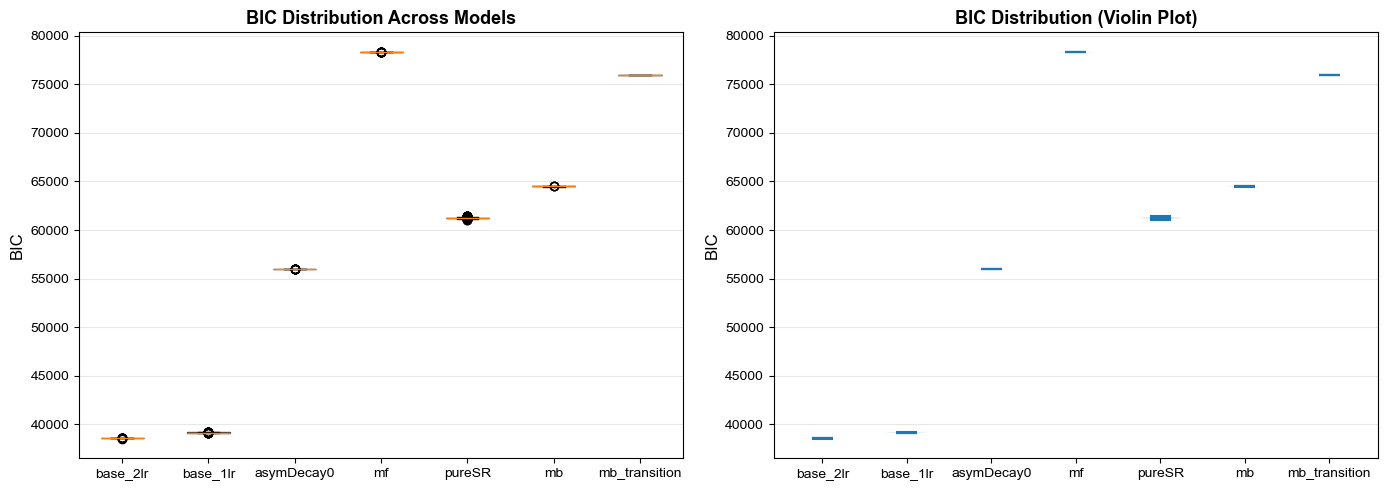


EFFECT SIZES (Cohen's d) - Heatmap Format

               base_2lr  base_1lr  asymDecay0        mf   pureSR        mb  \
base_2lr          0.000   -36.421   -2113.052 -3413.034 -605.280 -2448.658   
base_1lr         36.421     0.000   -1214.589 -2428.957 -565.503 -1648.282   
asymDecay0     2113.052  1214.589       0.000 -2439.355 -142.745 -1095.595   
mf             3413.034  2428.957    2439.355     0.000  453.511  1222.396   
pureSR          605.280   565.503     142.745  -453.511    0.000   -87.195   
mb             2448.658  1648.282    1095.595 -1222.396   87.195     0.000   
mb_transition  4824.544  2707.810    7018.400  -276.042  400.574  1581.268   

               mb_transition  
base_2lr           -4824.544  
base_1lr           -2707.810  
asymDecay0         -7018.400  
mf                   276.042  
pureSR              -400.574  
mb                 -1581.268  
mb_transition          0.000  

Interpretation: Positive values = Model1 has higher (worse) BIC than Model2
Negati

In [68]:
# Visualization: BIC distributions with box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of all models
ax = axes[0]
data_for_box = [model_bics[m] for m in model_names]
bp = ax.boxplot(data_for_box, labels=model_names, patch_artist=True)

# Color boxes
colors = ['#2ecc71', '#3498db', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('BIC', fontsize=12)
ax.set_title('BIC Distribution Across Models', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Violin plot for better visualization
ax = axes[1]
parts = ax.violinplot(data_for_box, positions=range(len(model_names)), 
                       showmeans=True, showmedians=True)

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=0)
ax.set_ylabel('BIC', fontsize=12)
ax.set_title('BIC Distribution (Violin Plot)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Effect size heatmap for pairwise comparisons
print("\n" + "=" * 80)
print("EFFECT SIZES (Cohen's d) - Heatmap Format")
print("=" * 80 + "\n")

# Create effect size matrix
es_matrix = pd.DataFrame(index=model_names, columns=model_names)
for model1 in model_names:
    for model2 in model_names:
        if model1 == model2:
            es_matrix.loc[model1, model2] = 0.0
        else:
            bic1 = model_bics[model1]
            bic2 = model_bics[model2]
            mean_diff = np.mean(bic1) - np.mean(bic2)
            pooled_std = np.sqrt((np.std(bic1, ddof=1)**2 + np.std(bic2, ddof=1)**2) / 2)
            es_matrix.loc[model1, model2] = mean_diff / pooled_std if pooled_std != 0 else 0

# Convert to float for display
es_matrix = es_matrix.astype(float)
print(es_matrix.round(3))

print("\nInterpretation: Positive values = Model1 has higher (worse) BIC than Model2")
print("Negative values = Model1 has lower (better) BIC than Model2")
print("Absolute value interpretation:")
print("  < 0.2: negligible, 0.2-0.5: small, 0.5-0.8: medium, > 0.8: large")
print("=" * 80)

In [70]:

import seaborn as sns

<>:64: SyntaxWarning: invalid escape sequence '\D'
<>:64: SyntaxWarning: invalid escape sequence '\D'
/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_73248/2933519763.py:64: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta$BIC (relative to best model)', fontsize=fontsize)


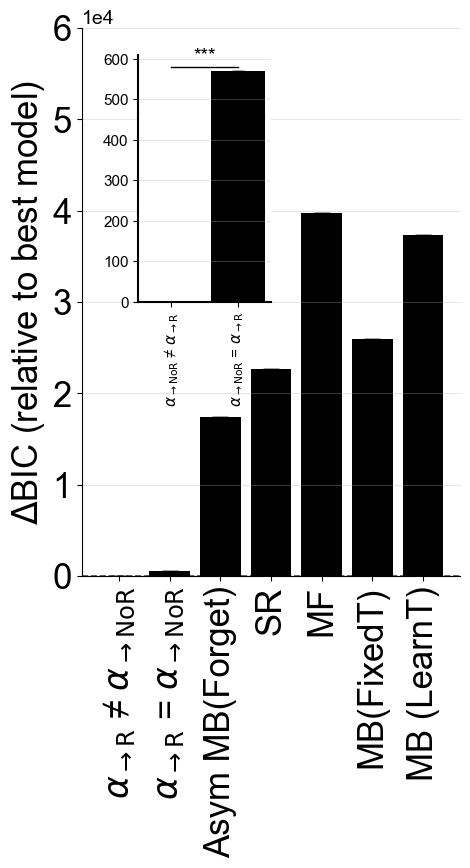

In [72]:
# Relative BIC (Delta BIC) with mean ± SEM error bars from repetitions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
# size2 = 35


fontsize = 25

# Ensure distribution data exists
if 'bic_random_samples_dist' not in globals() or bic_random_samples_dist is None or len(bic_random_samples_dist) == 0:
    raise RuntimeError("bic_random_samples_dist not found. Run the BIC repetition cell first.")

# Use model order if already defined, else from dict keys
# models = models if 'models' in globals() else list(bic_random_samples_dist.keys())
models = ['base_2lr', 'base_1lr', 'asymDecay0','pureSR', 'mf','mb','mb_transition']

# Build a DataFrame of BICs (rows = repetitions, cols = models)
bic_df = pd.DataFrame({m: np.asarray(bic_random_samples_dist[m]) for m in models})

# Compute delta per repetition relative to the best model that repetition (model base_2lr)
# min_per_rep = bic_df.min(axis=1)
min_per_rep = bic_df['base_2lr']
delta_df = bic_df.sub(min_per_rep, axis=0)

# Summary stats: mean and SEM for delta BIC per model
stats_rows = []
for m in models:
    vals = delta_df[m].values
    mean = float(np.mean(vals))
    sem = float(np.std(vals, ddof=1) / np.sqrt(len(vals)))
    stats_rows.append({
        'Model': m,
        'Mean ΔBIC': mean,
        'SEM': sem
    })

stats_df = pd.DataFrame(stats_rows)

# Plot bar chart with symmetric SEM error bars
means = stats_df['Mean ΔBIC'].values
yerr = stats_df['SEM'].values

# use Arial font
plt.rcParams['font.family'] = 'Arial'

##################

fig, ax = plt.subplots(1, 1, figsize=(5, 6))

mpl.rcParams['svg.fonttype'] = 'none'  # IMPORTANT
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']# size1 = 30

bars = ax.bar([0,1,2,3,4,5,6], means, yerr=yerr, capsize=6, color='black', linewidth=1.5)

# Add labels on bars
# for bar, mean in zip(bars, means):
#     h = bar.get_height()
#     ax[0].text(bar.get_x() + bar.get_width()/2., h,
#             f"{h:.1f}", ha='center', va='bottom', fontsize=11)

ax.set_ylabel('$\Delta$BIC (relative to best model)', fontsize=fontsize)
# ax.set_title('Relative BIC by Model (Mean ± SEM)', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
sns.despine()

# change ticks
ax.tick_params(axis='both', labelsize=11)
plt.xticks(fontsize=fontsize, rotation=45)

models_labels = [r'$\alpha_{\rightarrow \mathrm{R}}$ ≠ $\alpha_{\rightarrow \mathrm{NoR}}$', 
                 r'$\alpha_{\rightarrow \mathrm{R}}$ = $\alpha_{\rightarrow \mathrm{NoR}}$', 'Asym MB(Forget)',
                 'SR', 'MF','MB(FixedT)', 'MB (LearnT)']
# replace ticks
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_xticks([0,1,2,3,4,5,6])
ax.set_xticklabels(models_labels, rotation=90, fontsize=fontsize)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.yaxis.offsetText.set_fontsize(14)  # or any size you prefer

ax.set_ylim([0,60000])



# use scienticific notation for y axis


# # show the model learning rates as zoom in

# bars = ax[1].bar([0,1,2,3], means, yerr=yerr, capsize=6, color='black', linewidth=1.5)

# # Add labels on bars
# # for bar, mean in zip(bars, means):
# #     h = bar.get_height()
# #     ax[0].text(bar.get_x() + bar.get_width()/2., h,
# #             f"{h:.1f}", ha='center', va='bottom', fontsize=11)

# # ax[1].set_ylabel('$\Delta$BIC (relative to best model)', fontsize=fontsize)
# # ax[1].set_title('Relative BIC by Model (Mean ± SEM)', fontsize=14, fontweight='bold')
# ax[1].axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
# ax[1].grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.ylim(0, 1000)
# sns.despine()
# ax[1].set_xticks([0,1,2,3])
# ax[1].set_xticklabels(models_labels, rotation=90, fontsize=fontsize)

# change ticks
plt.yticks(fontsize=fontsize)
plt.xticks(fontsize=fontsize)

# plt.savefig('Figures/SGM2026_FigureSI_modelComparison_withSR.svg', format='svg')
plt.savefig('Figures/SGM2026_FigureSI_modelComparison_withSR_v2.svg', format='svg')

# Add inset showing the first two models with significance
axins = ax.inset_axes([0.15, 0.5, 0.35, 0.45])  # [x, y, width, height] in axes coordinates

# Plot the same data as the second figure in the inset
bars_inset = axins.bar([0,1], means[0:2], yerr=yerr[0:2], capsize=4, color='black', linewidth=1.0)
axins.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
axins.grid(axis='y', alpha=0.3)

# Add significance asterisks
max_height = max(means[0:2] + yerr[0:2])
asterisk_y = max_height + 10
axins.plot([0, 1], [asterisk_y, asterisk_y], color='black', linewidth=1.0)
axins.text(0.5, asterisk_y + 5, '***', ha='center', va='bottom', fontsize=14)

#### Set inset properties ####
models_labels_inset = [r'$\alpha_{\rightarrow \mathrm{NoR}}$ ≠ $\alpha_{\rightarrow \mathrm{R}}$', 
                 r'$\alpha_{\rightarrow \mathrm{NoR}}$ = $\alpha_{\rightarrow \mathrm{R}}$']
axins.set_xticks([0,1])
axins.set_xticklabels(models_labels_inset, rotation=90, fontsize=50)
axins.tick_params(axis='both', labelsize=11)
# axins.set_ylim(0, 150)
sns.despine(ax=axins)

# Add frame to the inset
for spine in axins.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.savefig('Figures/SGM2026_stay&forget_FigureSI_modelComparison_withAsymDecay_withSR_with_inset_v3.svg', format='svg')

plt.show()



$\Delta$BIC (Delta from best per repetition) with SEM
        Model    Mean ΔBIC      SEM
     base_2lr     0.000000 0.000000
     base_1lr   569.542648 0.350481
   asymDecay0 17427.496636 0.186979
       pureSR 22675.280810 0.837308
           mf 39760.286633 0.258132
           mb 25932.794162 0.238588
mb_transition 37357.713622 0.173145

Interpretation: Lower ΔBIC is better; error bars show SEM across repetitions.


<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:62: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:62: SyntaxWarning: invalid escape sequence '\D'
/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_73248/298563352.py:17: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta$BIC', fontsize=fontsize)
/var/folders/6r/rzypfly12y1gcgr6p0wlj9zm0000gs/T/ipykernel_73248/298563352.py:62: SyntaxWarning: invalid escape sequence '\D'
  print("$\Delta$BIC (Delta from best per repetition) with SEM")


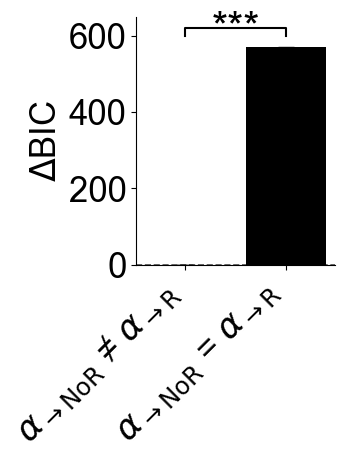

In [74]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(1, 1, figsize=(3, 3))

mpl.rcParams['svg.fonttype'] = 'none'  # IMPORTANT
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']# size1 = 30

bars = ax.bar([0,1], means[0:2], yerr=yerr[0:2], capsize=6, color='black', linewidth=1.5)

# Add labels on bars
# for bar, mean in zip(bars, means):
#     h = bar.get_height()
#     ax[0].text(bar.get_x() + bar.get_width()/2., h,
#             f"{h:.1f}", ha='center', va='bottom', fontsize=11)

ax.set_ylabel('$\Delta$BIC', fontsize=fontsize)
# ax.set_title('Relative BIC by Model (Mean ± SEM)', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
# ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
sns.despine()

# change ticks
plt.yticks(fontsize=fontsize)
plt.xticks(fontsize=fontsize, rotation=45)
models_labels = [r'$\alpha_{\rightarrow \mathrm{NoR}}$ ≠ $\alpha_{\rightarrow \mathrm{R}}$', 
                 r'$\alpha_{\rightarrow \mathrm{NoR}}$ = $\alpha_{\rightarrow \mathrm{R}}$']
# replace ticks
ax.set_xticks([0,1])
ax.set_xticklabels(models_labels, rotation=45, fontsize=fontsize,ha='right')
# plt.xlim(-1,1.2)

# reduce ticks numbers

ax.yaxis.set_major_locator(ticker.MaxNLocator(4))

lr_base_data = means[0]
lr_rew_data = means[1]
# add significance asterisks to this plot
# get max height
from scipy.stats import ttest_rel
p_value = results_df.iloc[0]['p-value']
if p_value < 0.001:
    plt.text(0.5, max(np.mean(lr_base_data),np.mean(lr_rew_data)+ 20), '***', fontsize=30, ha='center')
# elif p_value < 0.01:
#     plt.text(1.5, max(np.mean(lr_base_data), np.mean(lr_rew_data)) + 0.05, '**', fontsize=30, ha='center')
# elif p_value < 0.05:
#     plt.text(1.5, max(np.mean(lr_base_data), np.mean(lr_rew_data)) + 0.05, '*', fontsize=30, ha='center')
# add lines between bars
plt.plot([0,0,1, 1], [max(lr_base_data,lr_rew_data) + 0.3*100,
                         max(lr_base_data,lr_rew_data) + 0.5*100,
                         max(lr_base_data,lr_rew_data) + 0.5*100,
                         max(lr_base_data,lr_rew_data) + 0.3*100], color='black')
# plt.ylim(0.2, 1.1 * max(lr_base_data,lr_rew_data) + 50)

# plt.ylim(0,140)
# save figure to 
plt.savefig('Figures/SGM2026_Figure5_stay&forget_modelComparison.svg', format='svg')

print("="*70)
print("$\Delta$BIC (Delta from best per repetition) with SEM")
print("="*70)
print(stats_df[['Model','Mean ΔBIC','SEM']].to_string(index=False))
print("\nInterpretation: Lower ΔBIC is better; error bars show SEM across repetitions.")


